# LIMOncello — Full pipeline của **một frame LiDAR** đi qua hệ thống

Notebook này nối các notebook rời trước đó thành một bức tranh end-to-end:

\[
\text{IMU propagation}
\rightarrow
\text{time sync}
\rightarrow
\text{deskew}
\rightarrow
\text{voxel/filter}
\rightarrow
\text{kNN + plane fitting}
\rightarrow
\text{iterated error-state update}
\rightarrow
\text{map insertion}
\]

Mục tiêu không phải thay thế C++ thật, mà là giúp bạn đọc code LIMOncello theo đúng trình tự runtime.  
Các cell Python bên dưới dùng mô phỏng nhỏ để minh họa hình học: scan bị méo khi robot chuyển động, deskew đưa các điểm về cùng mốc thời gian, residual point-to-plane kéo pose về map, rồi frame sau khi hội tụ được chèn vào i-Octree.

Nguồn chính được notebook này bám theo:

- Paper LIMOncello, đặc biệt Fig. 2 và Sec. III-A–E.
- `src/main.cpp`: `Manager`, `imu_callback`, `process_cloud`.
- `include/Core/Cloud.hpp`: `filter_states`, `deskew`, `voxel_grid`, `filter`.
- `include/Core/State.hpp`: `predict`, `interpolate_to`, `update`.
- `include/Core/Plane.hpp`: `estimate_plane`, `dist2plane`.
- `include/Core/Octree.hpp`: `knn`, `update`.

## 0. Bản đồ tư duy: một frame LiDAR đi qua những khối nào?

Trong paper, sơ đồ hệ thống là:

\[
\text{IMU, LiDAR}
\rightarrow
\text{Forward Propagation}
\rightarrow
\text{Motion Compensation}
\rightarrow
\text{Voxel Grid Downsampling}
\rightarrow
\text{Residual Computation}
\leftrightarrow
\text{State Update}
\rightarrow
\text{Point-wise Insertion}
\rightarrow
\text{i-Octree}
\]

Trong code, trình tự này hiện ra rõ nhất trong `process_cloud(...)`:

```cpp
PointCloudT::Ptr raw = producer();

min_at_front_max_at_back(raw);
PointTime point_time = point_time_func();

offset = ...;                         // optional time sync
start_stamp = point_time(raw->front(), sweep_time) + offset;
end_stamp   = point_time(raw->back(),  sweep_time) + offset;

States interpolated = filter_states(state_buffer_, start_stamp, end_stamp);

PointCloudT::Ptr deskewed    = deskew(raw, state_, interpolated, offset, sweep_time);
PointCloudT::Ptr downsampled = voxel_grid(deskewed);
PointCloudT::Ptr filtered    = filter(downsampled, T_lidar_to_baselink);

state_.update(filtered, ioctree_);

T = state_.isometry() * state_.L2I_isometry();
pcl::transformPointCloud(*deskewed, *global, T);
pcl::transformPointCloud(*filtered, *to_save, T);

ioctree_.update(to_save->points);
```

Hãy nhớ rằng **`state_.update(filtered, ioctree_)` dùng cloud đang ở frame LiDAR cuối scan**, còn **`ioctree_.update(to_save->points)` chèn cloud đã transform sang world**.

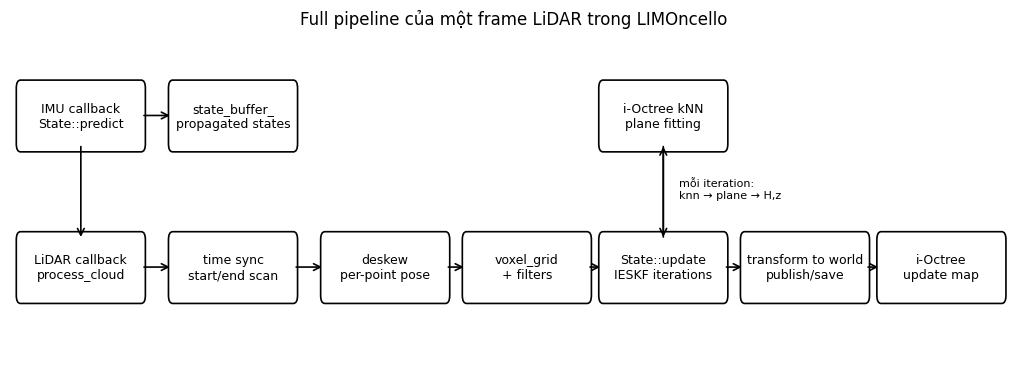

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

def box(ax, xy, text, width=2.3, height=0.55):
    patch = FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.08",
        linewidth=1.2,
        fill=False
    )
    ax.add_patch(patch)
    ax.text(xy[0] + width/2, xy[1] + height/2, text,
            ha="center", va="center", fontsize=9)
    return patch

def arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                 mutation_scale=12, linewidth=1.2))

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.axis("off")

nodes = [
    ((0.2, 2.5), "IMU callback\nState::predict"),
    ((0.2, 1.0), "LiDAR callback\nprocess_cloud"),
    ((3.1, 2.5), "state_buffer_\npropagated states"),
    ((3.1, 1.0), "time sync\nstart/end scan"),
    ((6.0, 1.0), "deskew\nper-point pose"),
    ((8.7, 1.0), "voxel_grid\n+ filters"),
    ((11.3, 1.0), "State::update\nIESKF iterations"),
    ((14.0, 1.0), "transform to world\npublish/save"),
    ((16.6, 1.0), "i-Octree\nupdate map"),
    ((11.3, 2.5), "i-Octree kNN\nplane fitting"),
]

for xy, text in nodes:
    box(ax, xy, text)

arrow(ax, (2.5, 2.78), (3.1, 2.78))
arrow(ax, (1.35, 2.5), (1.35, 1.55))
arrow(ax, (2.5, 1.28), (3.1, 1.28))
arrow(ax, (5.4, 1.28), (6.0, 1.28))
arrow(ax, (8.3, 1.28), (8.7, 1.28))
arrow(ax, (11.0, 1.28), (11.3, 1.28))
arrow(ax, (13.6, 1.28), (14.0, 1.28))
arrow(ax, (16.3, 1.28), (16.6, 1.28))
arrow(ax, (12.45, 1.55), (12.45, 2.5))
arrow(ax, (12.45, 2.5), (12.45, 1.55))

ax.text(12.75, 2.05, "mỗi iteration:\nknn → plane → H,z", fontsize=8, va="center")
ax.set_xlim(0, 19.2)
ax.set_ylim(0.4, 3.6)
plt.title("Full pipeline của một frame LiDAR trong LIMOncello")
plt.show()

## 1. Giai đoạn IMU: `imu_callback(...)` cập nhật state liên tục

Trong `imu_callback`, mỗi IMU mới tạo ra một object `Imu` rồi gọi:

```cpp
double dt = imu.stamp - prev_imu_.stamp;
state_.predict(imu, dt);
state_buffer_.push_front(state_);
```

Về toán, đây là prediction của IESKF:

\[
\hat x_{k+1} = \hat x_k \boxplus f(\hat x_k, u_k, 0),
\]

\[
\hat P_{k+1} = F_x \hat P_k F_x^\top + F_w Q F_w^\top.
\]

Trong `State.hpp`, increment chính nằm trong `f(...)`:

\[
f(x,u,0)=
\begin{bmatrix}
0\\
a_m-b_a-R^\top g\\
\omega_m-b_\omega\\
1\\
0\\
0\\
0\\
0
\end{bmatrix}.
\]

Ý nghĩa:

- `a_m - b_a - R.transpose()*g()` là gia tốc đã bù bias và gravity, biểu diễn trong frame IMU/body.
- `omega_m - b_w` là vận tốc góc đã bù bias.
- `1` là phần thời gian nội tại của `SGal(3)`.
- `state_buffer_` là lịch sử các state đã propagate bằng IMU, dùng cho deskew từng điểm LiDAR.

## 2. Đồng bộ thời gian của một scan LiDAR

Trong `process_cloud(...)`, code không giả định mọi điểm trong scan có cùng timestamp. Nó dùng:

```cpp
min_at_front_max_at_back(raw);
PointTime point_time = point_time_func();

start_stamp = point_time(raw->points.front(), sweep_time) + offset;
end_stamp   = point_time(raw->points.back(),  sweep_time) + offset;
```

Với một điểm LiDAR \(p_i\), timestamp thực tế của nó có dạng:

\[
t_i = t_\text{sweep} + \Delta t_i + t_\text{offset}.
\]

Trong đó:

- \(t_\text{sweep}\) là timestamp message ROS.
- \(\Delta t_i\) là relative time của điểm trong scan.
- \(t_\text{offset}\) là căn chỉnh thô giữa LiDAR và IMU nếu bật `cfg.sensors.time_offset`.

Code còn đợi IMU propagate đủ xa:

```cpp
if (state_buffer_.front().stamp < end_stamp)
    cv_prop_stamp_.wait(...);
```

Nghĩa là: **không deskew khi chưa có state IMU phủ đến cuối scan**.

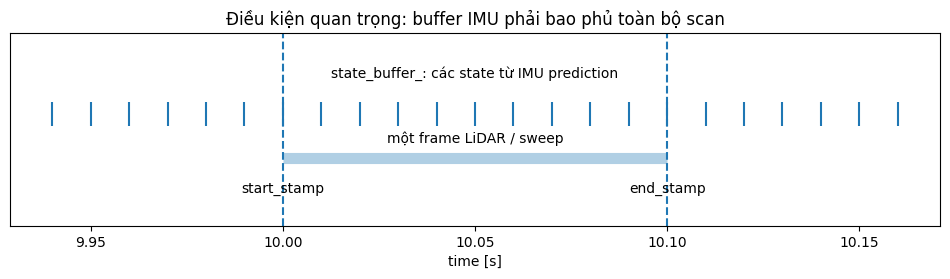

In [2]:
# Minh họa state_buffer_ phủ lên một frame LiDAR

sweep_start = 10.000
sweep_duration = 0.100
sweep_end = sweep_start + sweep_duration
imu_times = np.arange(9.94, 10.16, 0.01)

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.hlines(0, sweep_start, sweep_end, linewidth=8, alpha=0.35)
ax.scatter(imu_times, np.zeros_like(imu_times) + 0.23, marker="|", s=300)
ax.axvline(sweep_start, linestyle="--")
ax.axvline(sweep_end, linestyle="--")

ax.text(sweep_start, -0.18, "start_stamp", ha="center")
ax.text(sweep_end, -0.18, "end_stamp", ha="center")
ax.text((sweep_start+sweep_end)/2, 0.08, "một frame LiDAR / sweep", ha="center")
ax.text(imu_times.mean(), 0.42, "state_buffer_: các state từ IMU prediction", ha="center")

ax.set_ylim(-0.35, 0.65)
ax.set_xlabel("time [s]")
ax.set_yticks([])
ax.set_title("Điều kiện quan trọng: buffer IMU phải bao phủ toàn bộ scan")
plt.show()

## 3. `filter_states(...)`: lấy cửa sổ state đủ để deskew

`filter_states(states, start, end)` duyệt `state_buffer_` và trả về các state nằm trong khoảng cần dùng:

```cpp
for (const auto& state : states) {
  if (state.stamp >= end) continue;
  if (state.stamp >= start) out.push_front(state);
  if (state.stamp < start) {
    out.push_front(state);
    break;
  }
}
```

Vì `state_buffer_` được `push_front`, phần tử mới nhất nằm ở `front`.  
Output cần có:

- một state trước hoặc tại `start_stamp`,
- các state giữa scan,
- state đủ gần trước `end_stamp`.

Trong `deskew(...)`, mỗi điểm sẽ binary search để tìm state gần nhất **không vượt quá timestamp của điểm**, rồi gọi:

```cpp
X0.interpolate_to(t_i);
```

Đây không phải nội suy tuyến tính kiểu lerp/slerp. Nó là một bước propagation ngắn bằng IMU cuối cùng đã lưu:

\[
X(t_i) \approx X(t_j)\boxplus f(a_j,\omega_j)(t_i-t_j), \quad t_j \le t_i.
\]

## 4. Deskew: đưa mọi điểm về cùng frame cuối scan

Trong `Cloud.hpp`, deskew có dòng cốt lõi:

```cpp
Eigen::Isometry3f T0 = (X0.isometry() * X0.L2I_isometry()).cast();
Eigen::Isometry3f TN = (state.isometry() * state.L2I_isometry()).cast();

p = TN.inverse() * T0 * p;
```

Ký hiệu:

\[
T_{WL_i} = T_{WI_i}T_{IL}
\]

là pose LiDAR tại thời điểm điểm \(i\) được quét, và

\[
T_{WL_N} = T_{WI_N}T_{IL}
\]

là pose LiDAR ở cuối scan. Khi đó deskew làm:

\[
p_i^{L_N}
=
T_{WL_N}^{-1}
T_{WL_i}
p_i^{L_i}.
\]

Sau deskew, toàn bộ cloud được biểu diễn như thể **tất cả điểm đều được đo tại frame LiDAR cuối scan**.  
Vì vậy sau `deskew(...)`, `state_.update(filtered, ioctree_)` có thể dùng một pose duy nhất cho cả frame.

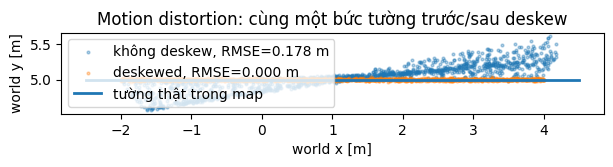

RMSE naive  : 0.1777 m
RMSE deskew : 0.0000 m


In [3]:
# Helper hình học SE(2)-trong-3D cho mô phỏng deskew.
# Đây chỉ là minh họa, không phải SGal(3) thật.

def Rz(yaw):
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, 0.0],
                     [s,  c, 0.0],
                     [0.0, 0.0, 1.0]])

def T_from_xyyaw(x, y, yaw):
    T = np.eye(4)
    T[:3, :3] = Rz(yaw)
    T[:3, 3] = [x, y, 0.0]
    return T

def inv_T(T):
    out = np.eye(4)
    R = T[:3, :3]
    t = T[:3, 3]
    out[:3, :3] = R.T
    out[:3, 3] = -R.T @ t
    return out

def transform_points(T, P):
    P_h = np.c_[P, np.ones(len(P))]
    return (T @ P_h.T).T[:, :3]

def pose_at(alpha):
    # alpha in [0,1]: robot vừa tịnh tiến vừa yaw trong một sweep.
    x = 0.0 + 1.2 * alpha
    y = 0.0 + 0.05 * np.sin(2*np.pi*alpha)
    yaw = 0.0 + 0.18 * alpha
    return T_from_xyyaw(x, y, yaw)

rng = np.random.default_rng(42)

# Tạo một scan nhìn vào tường y=5 trong world.
N = 1400
alpha = np.linspace(0, 1, N)
x_wall = rng.uniform(-2.0, 4.0, size=N)
z_wall = rng.uniform(-1.0, 1.5, size=N)
world_points = np.c_[x_wall, np.full(N, 5.0), z_wall]
world_points += rng.normal(scale=0.01, size=world_points.shape)

# Mỗi điểm được đo ở một pose khác nhau trong sweep.
raw_local = np.empty_like(world_points)
for k, a in enumerate(alpha):
    Ti = pose_at(a)
    raw_local[k] = transform_points(inv_T(Ti), world_points[k:k+1])[0]

T_end = pose_at(1.0)

# Nếu không deskew: lấy mọi raw_local như thể đo tại cuối scan.
naive_world = transform_points(T_end, raw_local)

# Deskew: p_end = T_end^-1 * T_i * p_i
deskewed_end_local = np.empty_like(raw_local)
for k, a in enumerate(alpha):
    Ti = pose_at(a)
    deskewed_end_local[k] = transform_points(inv_T(T_end) @ Ti, raw_local[k:k+1])[0]

deskewed_world = transform_points(T_end, deskewed_end_local)

rmse_naive = np.sqrt(np.mean((naive_world[:, :2] - world_points[:, :2])**2))
rmse_deskew = np.sqrt(np.mean((deskewed_world[:, :2] - world_points[:, :2])**2))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(naive_world[:, 0], naive_world[:, 1], s=4, alpha=0.35, label=f"không deskew, RMSE={rmse_naive:.3f} m")
ax.scatter(deskewed_world[:, 0], deskewed_world[:, 1], s=4, alpha=0.35, label=f"deskewed, RMSE={rmse_deskew:.3f} m")
ax.plot([-2.5, 4.5], [5, 5], linewidth=2, label="tường thật trong map")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x [m]")
ax.set_ylabel("world y [m]")
ax.set_title("Motion distortion: cùng một bức tường trước/sau deskew")
ax.legend()
plt.show()

print(f"RMSE naive  : {rmse_naive:.4f} m")
print(f"RMSE deskew : {rmse_deskew:.4f} m")

## 5. Voxel grid và filter: giảm số điểm trước update

Sau deskew, code làm:

```cpp
PointCloudT::Ptr downsampled = voxel_grid(deskewed);
PointCloudT::Ptr filtered = filter(downsampled, cfg.sensors.extrinsics.imu2baselink * state_.L2I_isometry());
```

`voxel_grid(...)` dùng PCL `VoxelGrid` với `leaf_size` từ config.  
Ý tưởng toán học đơn giản:

\[
\mathcal V(p) =
\left(
\left\lfloor \frac{x}{l_x}\right\rfloor,
\left\lfloor \frac{y}{l_y}\right\rfloor,
\left\lfloor \frac{z}{l_z}\right\rfloor
\right)
\]

Mỗi voxel chỉ giữ một đại diện, thường là centroid:

\[
\bar p_v = \frac{1}{|\mathcal P_v|}\sum_{p_i\in \mathcal P_v}p_i.
\]

`filter(...)` sau đó loại điểm theo các điều kiện như:

- quá gần sensor,
- nằm trong crop box cần bỏ,
- sampling theo rate,
- ngoài field-of-view.

In [4]:
def voxel_grid(points, leaf=0.18):
    keys = np.floor(points / leaf).astype(int)
    buckets = {}
    for k, p in zip(map(tuple, keys), points):
        buckets.setdefault(k, []).append(p)
    centroids = np.array([np.mean(v, axis=0) for v in buckets.values()])
    return centroids

def simple_filter(points, min_distance=0.5, fov=np.deg2rad(130)):
    dist = np.linalg.norm(points[:, :2], axis=1)
    angle = np.abs(np.arctan2(points[:, 1], points[:, 0]))
    return points[(dist > min_distance) & (angle < fov)]

downsampled_local = voxel_grid(deskewed_end_local, leaf=0.18)
filtered_local = simple_filter(downsampled_local)

summary = pd.DataFrame({
    "stage": ["raw cloud", "deskewed", "voxel_grid", "filter"],
    "frame": ["mixed LiDAR times", "LiDAR end frame", "LiDAR end frame", "LiDAR end frame"],
    "number_of_points": [len(raw_local), len(deskewed_end_local), len(downsampled_local), len(filtered_local)]
})
summary

,stage,frame,number_of_points
0,raw cloud,mixed LiDAR times,1400
1,deskewed,LiDAR end frame,1400
2,voxel_grid,LiDAR end frame,520
3,filter,LiDAR end frame,520


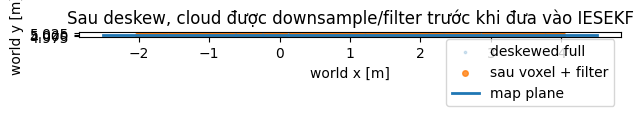

In [5]:
filtered_world_gt = transform_points(T_end, filtered_local)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(deskewed_world[:, 0], deskewed_world[:, 1], s=3, alpha=0.18, label="deskewed full")
ax.scatter(filtered_world_gt[:, 0], filtered_world_gt[:, 1], s=16, alpha=0.8, label="sau voxel + filter")
ax.plot([-2.5, 4.5], [5, 5], linewidth=2, label="map plane")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x [m]")
ax.set_ylabel("world y [m]")
ax.set_title("Sau deskew, cloud được downsample/filter trước khi đưa vào IESEKF")
ax.legend()
plt.show()

## 6. Residual computation: `map.knn(...) → estimate_plane(...) → dist2plane(...)`

Trong `State::update(...)`, với mỗi điểm \(p_i\) trong cloud đã deskew và filter:

```cpp
Vec<3> p = pt.getVector3fMap().cast<double>();
Vec<3> g = s.isometry() * s.L2I_isometry() * p; // global coords

map.knn(g, cfg.ikfom.plane.points, neighbors, distances);

estimate_plane(p_abcd, neighbors, cfg.ikfom.plane.plane_threshold);

z(i) = -dist2plane(m.n, g);
```

Ba công thức lõi:

### 6.1 Biến đổi điểm LiDAR sang world

\[
g_i = T_{WI}T_{IL}p_i.
\]

### 6.2 Fit mặt phẳng bằng PCA

Với k láng giềng \(q_j\):

\[
c = \frac{1}{k}\sum_{j=1}^k q_j,
\]

\[
C = \frac{1}{k}\sum_{j=1}^k (q_j-c)(q_j-c)^\top.
\]

Normal \(n\) là eigenvector ứng với eigenvalue nhỏ nhất của \(C\).  
Hệ số mặt phẳng:

\[
d=-n^\top c.
\]

### 6.3 Residual point-to-plane

\[
r_i = n_i^\top g_i + d_i.
\]

Trong code:

\[
z_i = -r_i.
\]

Dấu âm chỉ là convention để bước update giải theo dạng nội bộ của filter.

In [6]:
# Tạo map hiện có: các điểm gần tường y=5.
M = 3500
map_x = rng.uniform(-3.0, 5.0, size=M)
map_z = rng.uniform(-1.2, 1.7, size=M)
map_points = np.c_[map_x, np.full(M, 5.0), map_z]
map_points += rng.normal(scale=0.015, size=map_points.shape)

def knn_bruteforce(points, query, k=12):
    d2 = np.sum((points - query)**2, axis=1)
    idx = np.argpartition(d2, k)[:k]
    idx = idx[np.argsort(d2[idx])]
    return points[idx], d2[idx]

def estimate_plane_np(pts):
    centroid = pts.mean(axis=0)
    centered = pts - centroid
    cov = centered.T @ centered / len(pts)
    vals, vecs = np.linalg.eigh(cov)
    normal = vecs[:, 0]
    normal = normal / np.linalg.norm(normal)
    # ổn định hướng normal cho minh họa
    if normal[1] < 0:
        normal = -normal
    d = -normal @ centroid
    return normal, d, centroid, vals

def dist2plane_np(normal, d, point):
    return normal @ point + d

# Giả sử pose trước update hơi sai.
T_pred = T_from_xyyaw(1.2 + 0.10, 0.00 + 0.35, 0.18 + 0.045)

# Lấy một query point.
query_local = filtered_local[len(filtered_local)//2]
query_world_pred = transform_points(T_pred, query_local[None, :])[0]
neighbors, d2 = knn_bruteforce(map_points, query_world_pred, k=20)
normal, d, centroid, eigvals = estimate_plane_np(neighbors)
residual = dist2plane_np(normal, d, query_world_pred)

print("plane normal n =", normal)
print("plane d        =", d)
print("eigenvalues    =", eigvals)
print("signed residual n^T g + d =", residual)

plane normal n = [0.0455 0.998  0.0435]
plane d        = -4.906562402177145
eigenvalues    = [0.0002 0.0087 0.0128]
signed residual n^T g + d = 0.22707462536735257


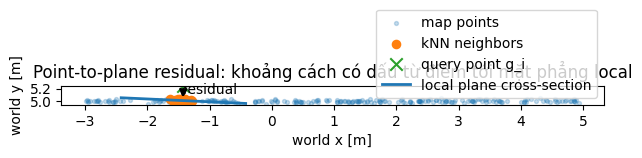

In [7]:
# Minh họa residual point-to-plane trong mặt cắt XY.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(map_points[::15, 0], map_points[::15, 1], s=8, alpha=0.25, label="map points")
ax.scatter(neighbors[:, 0], neighbors[:, 1], s=35, label="kNN neighbors")
ax.scatter([query_world_pred[0]], [query_world_pred[1]], s=80, marker="x", label="query point g_i")

# đường mặt phẳng yấp xỉ trong mặt cắt XY: n_x x + n_y y + d' = 0, lấy z của query
xs = np.linspace(query_world_pred[0]-1.0, query_world_pred[0]+1.0, 100)
if abs(normal[1]) > 1e-6:
    ys = -(normal[0]*xs + normal[2]*query_world_pred[2] + d) / normal[1]
    ax.plot(xs, ys, linewidth=2, label="local plane cross-section")

# chân đường vuông góc
foot = query_world_pred - residual * normal
ax.annotate("", xy=(foot[0], foot[1]), xytext=(query_world_pred[0], query_world_pred[1]),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.text((foot[0]+query_world_pred[0])/2, (foot[1]+query_world_pred[1])/2,
        "residual", fontsize=10, ha="left")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x [m]")
ax.set_ylabel("world y [m]")
ax.set_title("Point-to-plane residual: khoảng cách có dấu từ điểm tới mặt phẳng local")
ax.legend()
plt.show()

## 7. Jacobian trong update: từ residual sang \(H\)

Paper viết measurement model:

\[
h_i(x)=u_i^\top\left(\pi(\Gamma)\,{}^IT_Lp_i-q_i\right).
\]

Trong code, cùng ý tưởng được viết dưới dạng:

\[
r_i = n_i^\top g_i + d_i,
\quad
g_i = T_{WI}T_{IL}p_i.
\]

`State::update(...)` fill `H` như sau:

```cpp
Mat<3, manif::SGal3d::DoF> J_s;
Vec<3> g = s.X.element<0>().act(s.L2I_isometry() * m.p, J_s);

H.block<1, SGal3::DoF>(i, 0) =
    m.n.head(3).transpose() * J_s;
```

Nếu bật estimate extrinsics:

```cpp
manif::SE3d(isometry() * L2I_isometry()).act(m.p, J_e);

H.block<1, SE3::DoF>(i, SGal3::DoF) =
    m.n.head(3).transpose() * J_e;
```

Về mặt ý nghĩa:

\[
H_i =
\frac{\partial r_i}{\partial x}
=
n_i^\top
\frac{\partial g_i}{\partial x}.
\]

Các bias IMU và gravity **không xuất hiện trực tiếp trong residual LiDAR**, nên block đo trực tiếp chỉ là `SGal3 + SE3`.  
Bias và gravity được sửa **gián tiếp** qua tương quan covariance \(P\).

## 8. Iterated update: residual được tính lại nhiều lần

Trong `State::update(...)`, code không linearize một lần rồi thôi. Nó lặp:

```cpp
do {
    h_model(*this, H, z);

    dx = X.minus(X_predicted, J_).coeffs().head(DoFS2);
    dx.tail(2) = S2::ominus(g(), g_pred);

    P = J_inv * P * J_inv.transpose();

    P_inv.topLeftCorner<DoFObs,DoFObs>() += H.transpose()*H/R;
    P_inv = P_inv.inverse();

    Kz = P_inv.topLeftCorner<DoFS2,DoFObs>() * H.transpose() * z / R;
    KH = ...;

    dx = Kz + (KH - I) * J_inv * dx;

    X = X.plus(tau);
    g(S2::oplus(g(), dx.tail(2)));

} while (not converged);
```

Bản MAP/Kalman trong paper có dạng:

\[
K_j =
(H_j^\top V^{-1}H_j+\hat P_j^{-1})^{-1}H_j^\top V^{-1},
\]

\[
\hat x_{j+1}
=
\hat x_j
\oplus
\left(
-K_jz_j
-
(I-K_jH_j)J_j^{-1}(\hat x_j\ominus\hat x)
\right).
\]

Điểm quan trọng với người mới:

- `h_model` được gọi lại mỗi iteration.
- Các mặt phẳng và residual được tính lại theo state hiện tại.
- Đây là lý do gọi là **Iterated** Error-State Kalman Filter.

In [8]:
# Mini-demo: update point-to-plane đơn giản cho một frame.
# Thay vì SGal(3)+SE3+S2, ta chỉ estimate [tx, ty, tz, yaw] để thấy residual giảm.
# Đây là mô phỏng ý tưởng, không phải implementation LIMOncello.

def transform_local_xyyaw(params, local_points):
    tx, ty, tz, yaw = params
    T = T_from_xyyaw(tx, ty, yaw)
    T[:3, 3] += np.array([0, 0, tz])
    return transform_points(T, local_points)

def solve_pose_point_to_plane(local_points, map_points, init_params, k=15, iters=8, lm=1e-4):
    params = np.array(init_params, dtype=float)
    rms_history = []
    param_history = [params.copy()]
    Gz = np.array([[0.0, -1.0, 0.0],
                   [1.0,  0.0, 0.0],
                   [0.0,  0.0, 0.0]])

    for _ in range(iters):
        R = Rz(params[3])
        residuals = []
        H_rows = []

        # Dùng subset để chạy nhanh
        for p in local_points[::max(1, len(local_points)//180)]:
            g = R @ p + params[:3]
            neigh, _ = knn_bruteforce(map_points, g, k=k)
            n, dd, _, _ = estimate_plane_np(neigh)
            r = n @ g + dd

            # dr/d[tx,ty,tz] = n^T
            # dr/dyaw = n^T d(R p)/dyaw = n^T R Gz p
            h = np.zeros(4)
            h[:3] = n
            h[3] = n @ (R @ (Gz @ p))
            residuals.append(r)
            H_rows.append(h)

        r = np.asarray(residuals)
        H = np.vstack(H_rows)
        rms_history.append(float(np.sqrt(np.mean(r**2))))

        # Gauss-Newton: solve H dx = -r
        A = H.T @ H + lm * np.eye(4)
        b = -H.T @ r
        dx = np.linalg.solve(A, b)
        params += dx
        param_history.append(params.copy())

        if np.max(np.abs(dx)) < 1e-5:
            break

    return params, np.array(rms_history), np.array(param_history)

# Pose thật cuối scan trong mô phỏng:
true_params = np.array([1.2, 0.0, 0.0, 0.18])

# Pose predicted có sai số:
init_params = true_params + np.array([0.10, 0.35, 0.0, 0.045])

est_params, rms_history, param_history = solve_pose_point_to_plane(
    filtered_local, map_points, init_params, k=20, iters=10
)

pd.DataFrame({
    "quantity": ["tx", "ty", "tz", "yaw"],
    "true": true_params,
    "initial_pred": init_params,
    "after_update_demo": est_params,
    "remaining_error": est_params - true_params
})

,quantity,true,initial_pred,after_update_demo,remaining_error
0,tx,1.20,1.300,1.010238,-0.189762
1,ty,0.00,0.350,0.000417,0.000417
2,tz,0.00,0.000,0.037703,0.037703
3,yaw,0.18,0.225,0.180024,0.000024


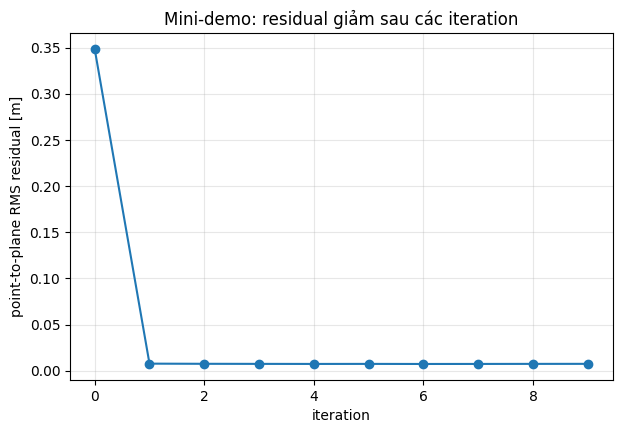

RMS history: [0.3486 0.0076 0.0075 0.0074 0.0073 0.0074 0.0073 0.0073 0.0074 0.0074]


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(len(rms_history)), rms_history, marker="o")
ax.set_xlabel("iteration")
ax.set_ylabel("point-to-plane RMS residual [m]")
ax.set_title("Mini-demo: residual giảm sau các iteration")
ax.grid(True, alpha=0.3)
plt.show()

print("RMS history:", rms_history)

## 9. Sau khi update hội tụ: transform và chèn vào i-Octree

Sau `state_.update(filtered, ioctree_)`, `process_cloud(...)` dùng state đã sửa:

```cpp
Eigen::Isometry3f T = (state_.isometry() * state_.L2I_isometry()).cast();

pcl::transformPointCloud(*deskewed, *global, T);
pcl::transformPointCloud(*filtered, *to_save, T);
```

Trong đó:

- `global` là deskewed full cloud để publish.
- `to_save` là filtered/downsampled cloud để đưa vào map.

Rồi:

```cpp
if (not stop_ioctree_update_)
    ioctree_.update(to_save->points);
```

Vì `to_save` đã ở world frame, i-Octree lưu map trong world frame.  
Ở frame kế tiếp, `State::update(...)` lại dùng `map.knn(...)` trên chính map này để tìm plane local.

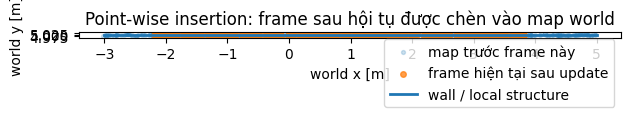

In [10]:
# Minh họa map trước/sau chèn frame hiện tại bằng pose sau update demo.
world_after_update = transform_local_xyyaw(est_params, filtered_local)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(map_points[::10, 0], map_points[::10, 1], s=8, alpha=0.22, label="map trước frame này")
ax.scatter(world_after_update[:, 0], world_after_update[:, 1], s=16, alpha=0.75, label="frame hiện tại sau update")
ax.plot([-3.0, 5.0], [5, 5], linewidth=2, label="wall / local structure")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("world x [m]")
ax.set_ylabel("world y [m]")
ax.set_title("Point-wise insertion: frame sau hội tụ được chèn vào map world")
ax.legend()
plt.show()

## 10. Bảng tổng kết biến chính trong một frame

| Bước | Code chính | Input | Output | Frame tọa độ |
|---|---|---|---|---|
| IMU propagation | `state_.predict(imu, dt)` | IMU raw | `state_`, `P`, `state_buffer_` | IMU/world |
| Time sync | `point_time_func`, `offset` | raw cloud + sweep time | `start_stamp`, `end_stamp` | time |
| State window | `filter_states` | `state_buffer_` | `interpolated` | time |
| Deskew | `deskew` | raw cloud + states | `deskewed` | LiDAR cuối scan |
| Downsample | `voxel_grid` | `deskewed` | `downsampled` | LiDAR cuối scan |
| Filter | `filter` | `downsampled` | `filtered` | LiDAR cuối scan |
| Correspondence | `map.knn`, `estimate_plane` | `filtered` + map | planes | world |
| IESEKF update | `state_.update` | `H,z,P` | corrected `state_`, `P` | manifold |
| Publish/map | `transformPointCloud`, `ioctree_.update` | corrected state + cloud | global cloud + map | world |

Cách nhớ ngắn nhất:

\[
\boxed{
\text{IMU đoán pose liên tục}
\rightarrow
\text{LiDAR deskew theo từng điểm}
\rightarrow
\text{LiDAR sửa pose bằng mặt phẳng map}
\rightarrow
\text{frame đã sửa được chèn vào map}
}
\]

## 11. Pseudocode end-to-end sát với code

```text
on IMU message:
    imu = fromROS(msg)
    if still calibrating:
        estimate initial gyro/accel bias and gravity alignment
    else:
        dt = imu.stamp - prev_imu.stamp
        imu.lin_accel = scale_matrix * imu.lin_accel
        state.predict(imu, dt)
        state_buffer.push_front(state)
        publish propagated odometry / TF

on LiDAR message:
    raw = decode cloud according to LiDAR type
    sort/reorder points by per-point time

    point_time = point_time_func()
    offset = optional software time offset

    start = time(first point) + offset
    end   = time(last point)  + offset

    wait until state_buffer.front().stamp >= end

    interpolated_states = filter_states(state_buffer, start, end)

    lock state:
        deskewed = deskew(raw, current_state, interpolated_states, offset, sweep_time)
        downsampled = voxel_grid(deskewed)
        filtered = filter(downsampled)

        state.update(filtered, ioctree)

        T_world_lidar = state.isometry() * state.L2I_isometry()

        global_full = T_world_lidar * deskewed
        global_filtered = T_world_lidar * filtered

        state_buffer[0] = state

    publish state and global_full

    if map update not stopped:
        ioctree.update(global_filtered.points)
```

## 12. Checklist debug khi hệ chạy không đúng

### A. Nếu deskew bị méo

Kiểm tra:

1. `point_time_func()` có đọc đúng relative time của từng loại LiDAR không.
2. `min_at_front_max_at_back(raw)` có thật sự đưa điểm cũ nhất ra front và mới nhất ra back không.
3. `state_buffer_.front().stamp >= end_stamp` có đúng không.
4. `time_offset` có làm scan bị đẩy quá khứ/tương lai quá nhiều không.
5. `interpolate_to(t)` có nhận `dt >= 0` không.

### B. Nếu update không hội tụ

Kiểm tra:

1. `filtered` có đủ điểm không.
2. `map.knn(...)` có trả đủ láng giềng không.
3. `pointSearchSqDis.back()` có vượt `max_sqrt_dist` không.
4. `estimate_plane(...)` có bị fail vì `plane_threshold` quá chặt không.
5. RMS residual point-to-plane có giảm qua từng iteration không.
6. `lidar_noise`, `tolerance`, `max_iters` có hợp lý không.

### C. Nếu map phình hoặc lệch

Kiểm tra:

1. Cloud chèn vào map có dùng **state sau update** không.
2. Có vô tình chèn raw/deskewed ở frame LiDAR thay vì world không.
3. `stop_ioctree_update_` có đang bật không.
4. Voxel leaf size và filter min-distance/FOV có phù hợp sensor không.

## 13. Công thức cần nhớ sau notebook này

### Deskew

\[
p_i^{L_N}
=
T_{WL_N}^{-1}T_{WL_i}p_i^{L_i}.
\]

### Prediction

\[
\hat x_{k+1}=\hat x_k\boxplus f(\hat x_k,u_k,0),
\qquad
\hat P_{k+1}=F_x\hat P_kF_x^\top+F_wQF_w^\top.
\]

### Plane fitting

\[
c=\frac{1}{k}\sum_jq_j,
\qquad
C=\frac{1}{k}\sum_j(q_j-c)(q_j-c)^\top,
\]

\[
n=\text{eigenvector}_{\lambda_\min}(C),
\qquad
d=-n^\top c.
\]

### Point-to-plane residual

\[
r_i=n_i^\top T_{WI}T_{IL}p_i+d_i.
\]

### Iterated update

\[
K_j=(H_j^\top V^{-1}H_j+\hat P_j^{-1})^{-1}H_j^\top V^{-1},
\]

\[
\hat x_{j+1}=
\hat x_j\oplus
\left(
-K_jz_j
-
(I-K_jH_j)J_j^{-1}(\hat x_j\ominus\hat x)
\right).
\]

Trong code LIMOncello, tất cả các công thức này được chia ra giữa `main.cpp`, `Cloud.hpp`, `State.hpp`, `Plane.hpp` và `Octree.hpp`.